# CHƯƠNG 6: PHÂN TÍCH PHÂN BIỆT (DISCRIMINANT ANALYSIS)

Trong Chương 5, chúng ta đã giải quyết bài toán phân loại bằng Hồi quy Logistic, một mô hình dựa trên việc ước lượng xác suất bằng phương pháp Hợp lý cực đại (MLE). Tuy nhiên, lịch sử thống kê đã ghi nhận một hướng tiếp cận hoàn toàn khác biệt, rực rỡ về mặt hình học và sâu sắc về mặt đại số tuyến tính: **Phân tích Phân biệt (Discriminant Analysis)**. 

Phương pháp này không xem bài toán phân loại là việc khớp một đường cong xác suất, mà là một bài toán **Giảm chiều dữ liệu có giám sát (Supervised Dimensionality Reduction)**. Chúng ta sẽ đi tìm một hệ quy chiếu mới, nơi mà các nhóm dữ liệu tự động tách rời nhau ra một cách rõ ràng nhất.

---

## 6.1. Ý tưởng cốt lõi của Linear Discriminant Analysis (LDA)

Linear Discriminant Analysis (LDA), hay Phân tích Phân biệt Tuyến tính, được phát triển lần đầu bởi ngài Ronald Fisher vào năm 1936. Trái ngược với Phân tích thành phần chính (PCA) ở Chương 4 - vốn là một kỹ thuật *không giám sát* (Unsupervised) chỉ quan tâm đến việc tối đa hóa tổng phương sai mà không cần biết nhãn của dữ liệu, LDA là một kỹ thuật *có giám sát* (Supervised).

**Ý tưởng cốt lõi:**
Giả sử bạn có dữ liệu đa chiều của hai nhóm khách hàng (Tốt và Xấu). Nếu bạn chiếu (project) toàn bộ dữ liệu này xuống một đường thẳng 1 chiều bất kỳ, các điểm dữ liệu của hai nhóm có thể sẽ đè lên nhau, lẫn lộn vào nhau. Nhiệm vụ của LDA là tìm ra **một hướng chiếu duy nhất (một vector $\mathbf{w}$)** sao cho khi các điểm dữ liệu rơi xuống đường thẳng đó, hai nhóm khách hàng sẽ bị đẩy ra xa nhau nhất có thể, đồng thời các cá thể trong cùng một nhóm sẽ co cụm lại sát nhau nhất.

### Case Study Kinh điển: Chỉ số Z-score của Edward Altman (1968)

Ứng dụng vĩ đại nhất của LDA trong lịch sử tài chính hiện đại chính là **Mô hình dự báo phá sản Z-score** của Giáo sư Edward Altman. Trước Altman, các chuyên gia tín dụng thường phân tích đơn biến: họ nhìn vào biên lợi nhuận, rồi lại nhìn vào tỷ lệ nợ, và đưa ra quyết định cảm tính.

Altman đã thu thập dữ liệu của 66 công ty sản xuất (33 công ty đã phá sản và 33 công ty sống sót) với 22 tỷ số tài chính khác nhau. Bằng cách áp dụng thuật toán LDA, Altman đã tìm ra một vector hình học (chứa 5 trọng số) tạo ra sự phân tách hoàn hảo nhất giữa sự sống và cái chết của doanh nghiệp. Phương trình phân biệt đó là:

$$Z = 1.2X_1 + 1.4X_2 + 3.3X_3 + 0.6X_4 + 0.999X_5$$

**Trong đó:**
- $X_1$: Vốn lưu động / Tổng tài sản (Thanh khoản).
- $X_2$: Lợi nhuận giữ lại / Tổng tài sản (Tích lũy sinh lời).
- $X_3$: EBIT / Tổng tài sản (Năng lực hoạt động cốt lõi).
- $X_4$: Giá trị thị trường của Vốn chủ sở hữu / Tổng nợ (Đòn bẩy thị trường).
- $X_5$: Doanh thu / Tổng tài sản (Vòng quay tài sản).

Bằng cách chiếu một không gian 5 chiều ($X_1$ đến $X_5$) xuống một trục 1 chiều duy nhất ($Z$), Altman đã thiết lập được ranh giới rõ ràng: 
- Nếu $Z > 2.99$: Công ty nằm trong "Vùng an toàn" (Safe Zone).
- Nếu $Z < 1.81$: Công ty nằm trong "Vùng nguy hiểm" (Distress Zone), nguy cơ phá sản cực cao.
- Quãng giữa là "Vùng xám" (Grey Zone).

Câu hỏi đặt ra là: Bằng cách nào toán học có thể tính ra chính xác các con số $1.2; 1.4; 3.3...$ kia? Điều này đưa chúng ta đến với nền tảng đại số của Fisher.

---

## 6.2. Nền tảng Toán học (Fisher’s Linear Discriminant)

Giả sử chúng ta có một tập dữ liệu gồm $N$ quan sát trong không gian $P$-chiều, được chia thành 2 lớp $C_1$ (Kích thước $N_1$) và $C_2$ (Kích thước $N_2$). 

Bước đầu tiên, ta tính Vector trung bình (Centroid) của từng lớp trong không gian gốc:
$$\mathbf{m}_1 = \frac{1}{N_1} \sum_{\mathbf{x} \in C_1} \mathbf{x} \quad \text{và} \quad \mathbf{m}_2 = \frac{1}{N_2} \sum_{\mathbf{x} \in C_2} \mathbf{x}$$

Giả sử ta có một vector $\mathbf{w}$ (kích thước $P \times 1$). Khi ta chiếu một điểm dữ liệu $\mathbf{x}$ lên vector này, ta thu được một giá trị vô hướng (scalar) 1 chiều: $y = \mathbf{w}^T \mathbf{x}$.

Hình chiếu trung bình của lớp 1 và lớp 2 trên trục $\mathbf{w}$ sẽ là: $\tilde{m}_1 = \mathbf{w}^T \mathbf{m}_1$ và $\tilde{m}_2 = \mathbf{w}^T \mathbf{m}_2$.

### 6.2.1. Định nghĩa các Ma trận Phân tán (Scatter Matrices)

Để đánh giá mức độ "tốt" của trục chiếu $\mathbf{w}$, Fisher đề xuất 2 đại lượng đo lường độ phân tán:

**1. Ma trận phân tán trong nội bộ lớp (Within-class scatter matrix - $\mathbf{S}_W$):**
Đại lượng này đo lường sự dao động (variance) của các quan sát *xung quanh tâm của chính nhóm đó*. Ta muốn đại lượng này sau khi chiếu phải **càng nhỏ càng tốt** (để các điểm cùng nhóm co cụm lại).

$$\mathbf{S}_W = \sum_{\mathbf{x} \in C_1} (\mathbf{x} - \mathbf{m}_1)(\mathbf{x} - \mathbf{m}_1)^T + \sum_{\mathbf{x} \in C_2} (\mathbf{x} - \mathbf{m}_2)(\mathbf{x} - \mathbf{m}_2)^T$$

*Giải nghĩa ký hiệu:* $(\mathbf{x} - \mathbf{m}_1)(\mathbf{x} - \mathbf{m}_1)^T$ là tích ngoài (Outer product) của vector độ lệch, tạo ra một ma trận hiệp phương sai chưa chuẩn hóa. $\mathbf{S}_W$ là một ma trận đối xứng kích thước $P \times P$.

**2. Ma trận phân tán giữa các lớp (Between-class scatter matrix - $\mathbf{S}_B$):**
Đại lượng này đo lường khoảng cách giữa tâm của nhóm 1 và tâm của nhóm 2. Ta muốn khoảng cách này sau khi chiếu phải **càng lớn càng tốt** (để ranh giới giữa 2 nhóm trở nên rõ ràng).

$$\mathbf{S}_B = (\mathbf{m}_1 - \mathbf{m}_2)(\mathbf{m}_1 - \mathbf{m}_2)^T$$

*Giải nghĩa ký hiệu:* Tương tự, đây là tích ngoài của vector nối 2 tâm định dạng một không gian ma trận $P \times P$. Chú ý rằng $\mathbf{S}_B$ luôn có hạng (Rank) bằng 1 vì nó được tạo ra từ một vector duy nhất.

---

### 6.2.2. Bài toán Tối ưu hóa Tỷ số Rayleigh (Rayleigh Quotient)

Phương sai (tổng bình phương khoảng cách) của toàn bộ dữ liệu chiếu lên trục $\mathbf{w}$ được biến đổi thành dạng toàn phương (Quadratic form):
- Độ phân tán nội bộ lớp trên trục chiếu: $\tilde{s}_W^2 = \mathbf{w}^T \mathbf{S}_W \mathbf{w}$
- Khoảng cách giữa 2 tâm trên trục chiếu: $(\tilde{m}_1 - \tilde{m}_2)^2 = \mathbf{w}^T \mathbf{S}_B \mathbf{w}$

Fisher đã thiết lập hàm mục tiêu $J(\mathbf{w})$ - được gọi là **Tỷ số Rayleigh** - như sau:

$$J(\mathbf{w}) = \frac{\text{Khoảng cách giữa các Tâm (Projected)}}{\text{Độ phân tán Nội bộ (Projected)}} = \frac{\mathbf{w}^T \mathbf{S}_B \mathbf{w}}{\mathbf{w}^T \mathbf{S}_W \mathbf{w}}$$

**Mục tiêu:** Tìm $\mathbf{w}$ để **Tối đa hóa** $J(\mathbf{w})$. 

### 6.2.3. Lời giải: Biến đổi về Bài toán Trị riêng (Eigenvalue Problem)

Để tìm cực đại của $J(\mathbf{w})$, ta lấy đạo hàm riêng của $J$ theo vector $\mathbf{w}$ và cho bằng $\mathbf{0}$.
Áp dụng quy tắc đạo hàm phân thức cho ma trận:

$$\frac{dJ}{d\mathbf{w}} = \frac{(2 \mathbf{S}_B \mathbf{w})(\mathbf{w}^T \mathbf{S}_W \mathbf{w}) - (2 \mathbf{S}_W \mathbf{w})(\mathbf{w}^T \mathbf{S}_B \mathbf{w})}{(\mathbf{w}^T \mathbf{S}_W \mathbf{w})^2} = 0$$

Giản ước tử số, ta có:
$$(\mathbf{w}^T \mathbf{S}_W \mathbf{w}) \mathbf{S}_B \mathbf{w} = (\mathbf{w}^T \mathbf{S}_B \mathbf{w}) \mathbf{S}_W \mathbf{w}$$

Chia cả 2 vế cho đại lượng vô hướng $(\mathbf{w}^T \mathbf{S}_W \mathbf{w})$, ta nhận thấy $\frac{\mathbf{w}^T \mathbf{S}_B \mathbf{w}}{\mathbf{w}^T \mathbf{S}_W \mathbf{w}}$ chính là đại lượng vô hướng $\lambda = J(\mathbf{w})$. Thay vào phương trình:

$$\mathbf{S}_B \mathbf{w} = \lambda \mathbf{S}_W \mathbf{w}$$

Nhân từ bên trái với ma trận nghịch đảo $\mathbf{S}_W^{-1}$ (giả định $\mathbf{S}_W$ không suy biến), ta thu được một trong những phương trình đẹp nhất của Thống kê đa biến:

$$(\mathbf{S}_W^{-1} \mathbf{S}_B) \mathbf{w} = \lambda \mathbf{w}$$

**Giải nghĩa Toán học Cực độ:**
Phương trình trên chính là định nghĩa kinh điển của **Bài toán Trị riêng (Eigenvalue Problem)** đối với ma trận $(\mathbf{S}_W^{-1} \mathbf{S}_B)$.
- $\mathbf{w}$ chính là **Vector riêng (Eigenvector)**. Nó chỉ ra hướng chiếu tối ưu nhất trong không gian $P$-chiều.
- $\lambda$ chính là **Trị riêng (Eigenvalue)** lớn nhất, biểu diễn giá trị cực đại của Tỷ số Rayleigh $J(\mathbf{w})$.

**Nghiệm rút gọn cho bài toán 2 Lớp (Đỉnh cao của trực giác):**
Trong trường hợp đặc biệt chỉ có 2 lớp, vì $\mathbf{S}_B = (\mathbf{m}_1 - \mathbf{m}_2)(\mathbf{m}_1 - \mathbf{m}_2)^T$, nên tích $\mathbf{S}_B \mathbf{w}$ sẽ luôn sinh ra một vector có hướng nằm dọc theo đường nối 2 tâm $(\mathbf{m}_1 - \mathbf{m}_2)$. Tức là $\mathbf{S}_B \mathbf{w} \propto (\mathbf{m}_1 - \mathbf{m}_2)$.

Thế vào phương trình $\mathbf{S}_B \mathbf{w} = \lambda \mathbf{S}_W \mathbf{w}$, ta lập tức suy ra hướng của vector $\mathbf{w}$ mà không cần phân rã Trị riêng phức tạp:

$$\mathbf{w} \propto \mathbf{S}_W^{-1} (\mathbf{m}_1 - \mathbf{m}_2)$$

Đây là kết luận vĩ đại của Fisher: Hướng phân loại tốt nhất **không phải** là hướng nối trực tiếp 2 tâm $(\mathbf{m}_1 - \mathbf{m}_2)$. Bạn phải lấy hướng đó nhân với ma trận nghịch đảo nội bộ $\mathbf{S}_W^{-1}$. Ma trận nghịch đảo này đóng vai trò "bóp méo" không gian để hóa giải hiện tượng Đa cộng tuyến giữa các biến, đưa dữ liệu về không gian đẳng hướng (isotropic) trước khi phân tách.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ------------------------------------------------------------------
# MÔ PHỎNG TOÁN HỌC FISHER'S LDA BẰNG NUMPY
# Mục tiêu: Tính thủ công vector W để thấy rõ bản chất Đại số tuyến tính
# ------------------------------------------------------------------
np.random.seed(42)

# 1. Sinh dữ liệu tài chính 2 chiều (VD: Hệ số Thanh khoản và Biên lợi nhuận)
# Lớp 1: Công ty Phá sản (Đỏ)
mean1 = np.array([2, 3])
cov1 = np.array([[1, 0.8], [0.8, 1]]) # Phương sai hiệp biến mạnh (Ellipse nghiêng)
C1 = np.random.multivariate_normal(mean1, cov1, 100)

# Lớp 2: Công ty Sống sót (Xanh)
mean2 = np.array([5, 6])
cov2 = np.array([[1, 0.8], [0.8, 1]])
C2 = np.random.multivariate_normal(mean2, cov2, 100)

# 2. Tính Vector Trung bình (Centroids)
m1 = np.mean(C1, axis=0)
m2 = np.mean(C2, axis=0)

# 3. Tính Ma trận phân tán trong nội bộ (Within-class Scatter Matrix - SW)
SW = np.zeros((2, 2))
for x in C1:
    x_minus_m = (x - m1).reshape(2, 1)
    SW += x_minus_m @ x_minus_m.T
for x in C2:
    x_minus_m = (x - m2).reshape(2, 1)
    SW += x_minus_m @ x_minus_m.T

# 4. Tính Vector chiếu tối ưu (Fisher's W)
# Công thức: W = SW_inverse * (m1 - m2)
SW_inv = np.linalg.inv(SW)
mean_diff = (m1 - m2).reshape(2, 1)
w_fisher = SW_inv @ mean_diff

# Chuẩn hóa vector W về độ dài = 1 để dễ hiển thị
w_fisher_norm = w_fisher / np.linalg.norm(w_fisher)

print("---- KẾT QUẢ TÍNH TOÁN MA TRẬN LDA ----")
print("Tâm Lớp 1 (Phá sản) m1 :", np.round(m1, 2))
print("Tâm Lớp 2 (Sống sót) m2:", np.round(m2, 2))
print("\nMa trận phân tán SW:\n", np.round(SW, 2))
print("\nVector chiếu tối ưu W (Hệ số Fisher):\n", np.round(w_fisher_norm.flatten(), 4))
print("\nGiải nghĩa: Phương trình phân biệt tương tự Z-score sẽ là: ")
print(f"Z = {w_fisher_norm[0][0]:.4f}*X1 + {w_fisher_norm[1][0]:.4f}*X2")


---- KẾT QUẢ TÍNH TOÁN MA TRẬN LDA ----
Tâm Lớp 1 (Phá sản) m1 : [2.1  3.12]
Tâm Lớp 2 (Sống sót) m2: [4.86 5.89]

Ma trận phân tán SW:
 [[176.97 143.1 ]
 [143.1  183.34]]

Vector chiếu tối ưu W (Hệ số Fisher):
 [-0.759  -0.6511]

Giải nghĩa: Phương trình phân biệt tương tự Z-score sẽ là: 
Z = -0.7590*X1 + -0.6511*X2


## 6.3. Định lý Bayes trong LDA: Góc nhìn Xác suất Sinh thành (Generative)

Trong mục 6.2, chúng ta đã tiếp cận LDA dưới góc độ **Hình học của Fisher** (tìm một phép chiếu tối đa hóa sự phân tách). Tuy nhiên, LDA còn sở hữu một nền tảng toán học thứ hai, thanh lịch và chặt chẽ không kém: **Góc nhìn Xác suất Sinh thành dựa trên Định lý Bayes**.

Trái với Hồi quy Logistic (một mô hình phân biệt - Discriminative Model) chỉ cố gắng ước lượng trực tiếp xác suất $P(Y|X)$, LDA cố gắng mô hình hóa sự phân phối của chính dữ liệu bên trong từng lớp $P(X|Y)$, sau đó dùng Định lý Bayes để lật ngược lại vấn đề.

### 6.3.1. Diễn giải Định lý Bayes

Giả sử biến phụ thuộc $G$ (Group) có $K$ lớp (với $k = 1, \dots, K$). 
Theo Định lý Bayes, Xác suất hậu nghiệm (Posterior probability) để một quan sát $\mathbf{x}$ thuộc về lớp $k$ được tính bằng:

$$P(G=k | X=\mathbf{x}) = \frac{f_k(\mathbf{x}) \pi_k}{\sum_{l=1}^K f_l(\mathbf{x}) \pi_l}$$

**Giải thích chi tiết các thành phần:**
- $\pi_k = P(G=k)$: Xác suất tiên nghiệm (Prior probability) của lớp $k$. Đây là tỷ lệ của lớp $k$ trong tổng thể (Ví dụ: Tỷ lệ công ty phá sản chung trên thị trường là 2%).
- $f_k(\mathbf{x}) = P(X=\mathbf{x} | G=k)$: Hàm mật độ xác suất (Density function) của $\mathbf{x}$ nếu biết chắc chắn nó xuất phát từ lớp $k$.
- Mẫu số $\sum f_l(\mathbf{x}) \pi_l$: Là định lý xác suất toàn phần, đóng vai trò như một hằng số chuẩn hóa để đảm bảo tổng xác suất bằng 1.

Để dự báo nhãn cho một khách hàng mới $\mathbf{x}$, ta chỉ cần tính tử số $f_k(\mathbf{x}) \pi_k$ cho tất cả các lớp $K$, và gán $\mathbf{x}$ vào lớp có giá trị lớn nhất.

### 6.3.2. Giả định Cốt lõi của LDA

Để tính được $f_k(\mathbf{x})$, LDA đưa ra hai giả định cực kỳ táo bạo và nghiêm ngặt:

**Giả định 1: Phân phối Chuẩn Đa biến (Multivariate Normality)**
Dữ liệu của các quan sát trong cùng một lớp $k$ tuân theo phân phối chuẩn đa biến với vector kỳ vọng $\boldsymbol{\mu}_k$ và ma trận hiệp phương sai $\boldsymbol{\Sigma}_k$.
$$f_k(\mathbf{x}) = \frac{1}{(2\pi)^{p/2} |\boldsymbol{\Sigma}_k|^{1/2}} \exp \left( -\frac{1}{2} (\mathbf{x} - \boldsymbol{\mu}_k)^T \boldsymbol{\Sigma}_k^{-1} (\mathbf{x} - \boldsymbol{\mu}_k) \right)$$

**Giả định 2: Ma trận Hiệp phương sai chung (Homoscedasticity across classes)**
Tất cả $K$ lớp đều dùng chung một ma trận hiệp phương sai duy nhất: $\boldsymbol{\Sigma}_k = \boldsymbol{\Sigma} \quad \forall k$.
Điều này có nghĩa là các "đám mây điểm" của các nhóm có thể nằm ở các vị trí khác nhau (khác $\boldsymbol{\mu}_k$), nhưng chúng phải có **cùng một hình dáng, độ phình và độ nghiêng** trong không gian $p$-chiều.

**Tại sao Giả định 2 lại tạo ra Ranh giới TUYẾN TÍNH (Linear Boundary)?**
Để so sánh lớp $k$ và lớp $l$, ta lấy Logarit tự nhiên của tỷ lệ xác suất hậu nghiệm (Log-odds):

$$\ln \frac{P(G=k | X=\mathbf{x})}{P(G=l | X=\mathbf{x})} = \ln \frac{f_k(\mathbf{x}) \pi_k}{f_l(\mathbf{x}) \pi_l} = \ln \frac{f_k(\mathbf{x})}{f_l(\mathbf{x})} + \ln \frac{\pi_k}{\pi_l}$$

Khi thay hàm $f_k(\mathbf{x})$ vào và thực hiện phép chia, các thành phần hằng số $\frac{1}{(2\pi)^{p/2} |\boldsymbol{\Sigma}|^{1/2}}$ triệt tiêu lẫn nhau. 
Đặc biệt, do khai triển phần số mũ: 
$$(\mathbf{x} - \boldsymbol{\mu}_k)^T \boldsymbol{\Sigma}^{-1} (\mathbf{x} - \boldsymbol{\mu}_k) = \mathbf{x}^T \boldsymbol{\Sigma}^{-1} \mathbf{x} - 2\boldsymbol{\mu}_k^T \boldsymbol{\Sigma}^{-1} \mathbf{x} + \boldsymbol{\mu}_k^T \boldsymbol{\Sigma}^{-1} \boldsymbol{\mu}_k$$

Vì $\boldsymbol{\Sigma}$ là dùng chung, thành phần bậc hai $\mathbf{x}^T \boldsymbol{\Sigma}^{-1} \mathbf{x}$ xuất hiện ở cả lớp $k$ và lớp $l$, nên khi trừ đi nhau, chúng **triệt tiêu hoàn toàn**.
Kết quả chỉ còn lại Hàm phân biệt tuyến tính (Linear Discriminant Function):

$$\delta_k(\mathbf{x}) = \mathbf{x}^T \boldsymbol{\Sigma}^{-1} \boldsymbol{\mu}_k - \frac{1}{2} \boldsymbol{\mu}_k^T \boldsymbol{\Sigma}^{-1} \boldsymbol{\mu}_k + \ln(\pi_k)$$

Vì phương trình trên hoàn toàn bậc 1 đối với $\mathbf{x}$, ranh giới quyết định (khi $\delta_k(\mathbf{x}) = \delta_l(\mathbf{x})$) là một **mặt phẳng siêu việt tuyến tính (Hyperplane)**.

---

## 6.4. Quadratic Discriminant Analysis (QDA): Khi quy luật bị phá vỡ

Chuyện gì sẽ xảy ra nếu giả định "Cùng ma trận hiệp phương sai" là một sự hoang tưởng trong thực tế? Ví dụ: Những công ty Tốt thường có sự ổn định tài chính, các chỉ số dao động trong một biên độ hẹp (Phương sai nhỏ). Ngược lại, các công ty Xấu, cận kề phá sản, thường chứng kiến sự biến động điên cuồng của dòng tiền và đòn bẩy (Phương sai cực lớn).

Khi $\boldsymbol{\Sigma}_k \neq \boldsymbol{\Sigma}_l$, ta buộc phải chuyển sang **Phân tích Phân biệt Bậc hai (Quadratic Discriminant Analysis - QDA)**.

### 6.4.1. Hàm phân biệt bậc hai (QDA)

Nếu giữ lại $\boldsymbol{\Sigma}_k$ riêng biệt cho từng lớp, định thức $|\boldsymbol{\Sigma}_k|$ không còn giống nhau, và đại lượng bậc hai $\mathbf{x}^T \boldsymbol{\Sigma}_k^{-1} \mathbf{x}$ không thể triệt tiêu. 
Hàm phân biệt lúc này là một phương trình bậc hai (Parabol, Ellipse, Hyperbol):

$$\delta_k(\mathbf{x}) = -\frac{1}{2} \ln |\boldsymbol{\Sigma}_k| - \frac{1}{2} (\mathbf{x} - \boldsymbol{\mu}_k)^T \boldsymbol{\Sigma}_k^{-1} (\mathbf{x} - \boldsymbol{\mu}_k) + \ln(\pi_k)$$

Đường ranh giới quyết định giữa lớp $k$ và lớp $l$ giờ đây là một đường cong uốn lượn, cho phép mô hình bọc lấy (wrap around) các đám mây dữ liệu có hình dáng bất đối xứng một cách tinh tế.

### 6.4.2. So sánh trực diện: Logistic vs. LDA vs. QDA

Khi nào một Nhà Khoa học Dữ liệu nên rút công cụ nào ra khỏi vỏ?

| Tiêu chí | Logistic Regression | Linear Discriminant Analysis (LDA) | Quadratic Discriminant Analysis (QDA) |
| :--- | :--- | :--- | :--- |
| **Mục tiêu Tối ưu** | Tối đa hóa Conditional Likelihood $P(Y|X)$. | Tối đa hóa Joint Likelihood $P(X, Y)$. | Tối đa hóa Joint Likelihood $P(X, Y)$ với $\Sigma_k$ riêng biệt. |
| **Giả định Phân phối** | KHÔNG CÓ giả định về phân phối của $X$. (Bền bỉ, Robust). | $X$ bắt buộc phải là Phân phối chuẩn đa biến. | $X$ bắt buộc phải là Phân phối chuẩn đa biến. |
| **Biến độc lập (X)** | Có thể dùng cả biến liên tục và biến giả (Dummy). | Chỉ nên dùng biến liên tục (Continuous). | Chỉ nên dùng biến liên tục (Continuous). |
| **Ranh giới (Boundary)** | Tuyến tính (Linear). | Tuyến tính (Linear). | Bậc hai (Quadratic - Đường cong). |
| **Số lượng Tham số (Nhu cầu Data)** | Cần ước lượng $p$ tham số $\beta$. (Hiệu quả khi ít Data). | Cần ước lượng $\mu_k$ và 1 ma trận $\Sigma$ chung. Kích thước mẫu $N$ nhỏ cũng chạy tốt. | Cần ước lượng $\mu_k$ và $K$ ma trận $\Sigma_k$. Tổng tham số tăng theo bình phương $p^2$. **Rất dễ bị Overfitting nếu dữ liệu không đủ lớn**. |
| **Ngoại lai (Outliers)** | Tương đối chịu lỗi nhờ hàm Sigmoid nén đuôi. | Cực kỳ nhạy cảm (Vì Outliers làm méo $\mu$ và $\Sigma$). | Cực kỳ nhạy cảm. |
| **Kết luận thực chiến** | Dùng làm Baseline. Luôn là lựa chọn số 1 trong Tài chính/Ngân hàng vì tính diễn giải (Odds Ratio) và sức chịu đựng. | Dùng khi dữ liệu có phân phối chuẩn rõ ràng, hoặc $N$ rất nhỏ gọn, hoặc bài toán có nhiều hơn 2 lớp (K > 2). | Chỉ dùng khi có cực kỳ nhiều dữ liệu ($N \gg p$) và tin chắc rằng phương sai của các lớp là hoàn toàn khác biệt. |

---

# THỰC HÀNH PYTHON: CHIẾN TRƯỜNG PHÂN LOẠI

Chúng ta sẽ giả lập một kịch bản rủi ro tài chính, nơi Khách hàng Tốt (Xanh) có độ dao động tài chính ổn định (phương sai nhỏ), trong khi Khách hàng Xấu (Đỏ) có độ dao động tài chính cực kỳ hoang dã (phương sai lớn, hình Elip dẹp).
Cùng quan sát cách LDA thất bại trong việc ôm lấy đường viền, trong khi QDA uốn cong ranh giới để giải cứu mô hình.

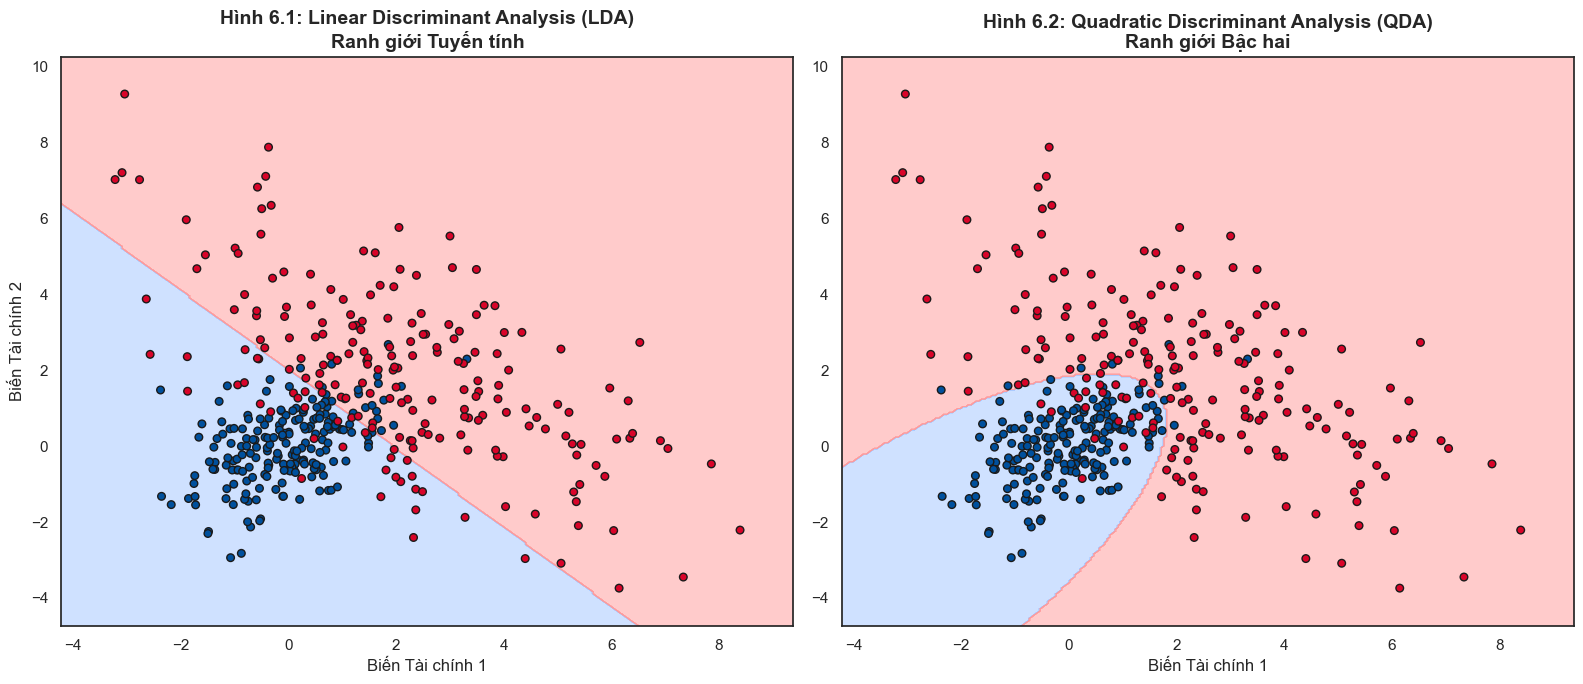

========== SO SÁNH ĐỘ CHÍNH XÁC (ACCURACY) ==========
LDA Accuracy : 86.0%
QDA Accuracy : 91.2%
=> Nhận xét: QDA cho độ chính xác cao hơn do nó bao bọc được đám mây điểm 'Tốt' (Màu xanh) đang nằm gọn bên trong sự phân tán dữ dội của lớp 'Xấu' (Màu đỏ).


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from matplotlib.colors import ListedColormap

# Thiết lập đồ họa
sns.set_theme(style="white")
np.random.seed(42)

# ========================================================
# BƯỚC 1: TẠO DỮ LIỆU VỚI MA TRẬN HIỆP PHƯƠNG SAI KHÁC NHAU
# ========================================================
# Lớp 0 (Khách hàng Tốt - Tụ tập dày đặc, Phương sai nhỏ)
mean_0 = [0, 0]
cov_0 = [[1, 0.5], 
         [0.5, 1]]
X_0 = np.random.multivariate_normal(mean_0, cov_0, 200)
y_0 = np.zeros(200)

# Lớp 1 (Khách hàng Vỡ nợ - Phân tán rộng, bao quanh Lớp 0)
mean_1 = [2, 2]
cov_1 = [[5, -3], 
         [-3, 5]] # Phương sai khổng lồ và tương quan âm
X_1 = np.random.multivariate_normal(mean_1, cov_1, 200)
y_1 = np.ones(200)

# Hợp nhất dữ liệu
X = np.vstack([X_0, X_1])
y = np.hstack([y_0, y_1])

# ========================================================
# BƯỚC 2: HUẤN LUYỆN MÔ HÌNH LDA VÀ QDA
# ========================================================
lda = LinearDiscriminantAnalysis()
lda.fit(X, y)

qda = QuadraticDiscriminantAnalysis()
qda.fit(X, y)

# ========================================================
# BƯỚC 3: TRỰC QUAN HÓA RANH GIỚI QUYẾT ĐỊNH (DECISION BOUNDARIES)
# ========================================================
# Tạo lưới tọa độ (Meshgrid) để tô màu vùng không gian
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                     np.arange(y_min, y_max, 0.05))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
cmap_light = ListedColormap(['#a0c4ff', '#ff9999'])
cmap_bold = ListedColormap(['#00509d', '#d90429'])

# Đồ thị 1: LDA
Z_lda = lda.predict(np.c_[xx.ravel(), yy.ravel()])
Z_lda = Z_lda.reshape(xx.shape)
axes[0].contourf(xx, yy, Z_lda, cmap=cmap_light, alpha=0.5)
axes[0].scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold, edgecolor='k', s=30)
axes[0].set_title('Hình 6.1: Linear Discriminant Analysis (LDA)\nRanh giới Tuyến tính', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Biến Tài chính 1')
axes[0].set_ylabel('Biến Tài chính 2')

# Đồ thị 2: QDA
Z_qda = qda.predict(np.c_[xx.ravel(), yy.ravel()])
Z_qda = Z_qda.reshape(xx.shape)
axes[1].contourf(xx, yy, Z_qda, cmap=cmap_light, alpha=0.5)
axes[1].scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold, edgecolor='k', s=30)
axes[1].set_title('Hình 6.2: Quadratic Discriminant Analysis (QDA)\nRanh giới Bậc hai', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Biến Tài chính 1')

plt.tight_layout()
plt.show()

# In Accuracy để so sánh
print("========== SO SÁNH ĐỘ CHÍNH XÁC (ACCURACY) ==========")
print(f"LDA Accuracy : {lda.score(X, y)*100:.1f}%")
print(f"QDA Accuracy : {qda.score(X, y)*100:.1f}%")
print("=> Nhận xét: QDA cho độ chính xác cao hơn do nó bao bọc được đám mây điểm 'Tốt' (Màu xanh) đang nằm gọn bên trong sự phân tán dữ dội của lớp 'Xấu' (Màu đỏ).")


# 6.5. Thực hành Python: Dự báo rủi ro phá sản bằng LDA và QDA

Trong phần thực hành này, chúng ta sẽ xây dựng một mô hình phân loại tình trạng tài chính của các doanh nghiệp dựa trên các tỷ số tài chính cốt lõi (tương tự tinh thần của chỉ số Altman Z-score). 

Mục tiêu là quan sát sự khác biệt thực tế giữa **Linear Discriminant Analysis (LDA)** và **Quadratic Discriminant Analysis (QDA)** khi đối mặt với dữ liệu có cấu trúc hiệp phương sai khác nhau giữa các nhóm doanh nghiệp Khỏe mạnh và doanh nghiệp Nguy cơ.

---

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
from matplotlib.colors import ListedColormap

# Thiết lập phong cách đồ họa chuyên nghiệp
sns.set_theme(style="whitegrid")
np.random.seed(42)

# ========================================================
# BƯỚC 1: GIẢ LẬP DỮ LIỆU TÀI CHÍNH DOANH NGHIỆP
# ========================================================
# Giả sử ta xét 2 chỉ số: 
# X1: EBIT / Tổng tài sản (Khả năng sinh lời)
# X2: Vốn lưu động / Tổng tài sản (Thanh khoản)

n_samples = 400

# Nhóm 0: Doanh nghiệp Khỏe mạnh (Healthy) - Ổn định, tương quan thuận vừa phải
mean_0 = [0.2, 0.3]
cov_0 = [[0.02, 0.01], [0.01, 0.02]]
X_healthy = np.random.multivariate_normal(mean_0, cov_0, n_samples // 2)
y_healthy = np.zeros(n_samples // 2)

# Nhóm 1: Doanh nghiệp Nguy cơ (Distressed) - Biến động mạnh, hiệp phương sai khác biệt
mean_1 = [-0.1, -0.05]
cov_1 = [[0.08, -0.04], [-0.04, 0.08]] # Phương sai lớn hơn và tương quan nghịch
X_distressed = np.random.multivariate_normal(mean_1, cov_1, n_samples // 2)
y_distressed = np.ones(n_samples // 2)

X = np.vstack([X_healthy, X_distressed])
y = np.hstack([y_healthy, y_distressed])

# Chia tập Train/Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Kích thước tập huấn luyện: {X_train.shape}")
print(f"Kích thước tập kiểm tra: {X_test.shape}")


Kích thước tập huấn luyện: (280, 2)
Kích thước tập kiểm tra: (120, 2)


### 6.5.1. Huấn luyện và So sánh Hiệu suất

Chúng ta sẽ thực hiện huấn luyện cả hai mô hình trên cùng một tập dữ liệu. Lưu ý rằng LDA cố gắng tìm một ma trận hiệp phương sai gộp (pooled covariance), trong khi QDA tính toán ma trận hiệp phương sai riêng cho từng nhóm.

In [4]:
# Khởi tạo mô hình
lda = LinearDiscriminantAnalysis(store_covariance=True)
qda = QuadraticDiscriminantAnalysis(store_covariance=True)

# Huấn luyện
lda.fit(X_train, y_train)
qda.fit(X_train, y_train)

# Dự báo
y_pred_lda = lda.predict(X_test)
y_pred_qda = qda.predict(X_test)

# In báo cáo kết quả
print("========== KẾT QUẢ PHÂN LOẠI LDA ==========")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lda):.4f}")
print(classification_report(y_test, y_pred_lda, target_names=['Khỏe mạnh', 'Nguy cơ']))

print("\n========== KẾT QUẢ PHÂN LOẠI QDA ==========")
print(f"Accuracy: {accuracy_score(y_test, y_pred_qda):.4f}")
print(classification_report(y_test, y_pred_qda, target_names=['Khỏe mạnh', 'Nguy cơ']))


========== KẾT QUẢ PHÂN LOẠI LDA ==========
Accuracy: 0.8583
              precision    recall  f1-score   support

   Khỏe mạnh       0.84      0.90      0.87        62
     Nguy cơ       0.89      0.81      0.85        58

    accuracy                           0.86       120
   macro avg       0.86      0.86      0.86       120
weighted avg       0.86      0.86      0.86       120


========== KẾT QUẢ PHÂN LOẠI QDA ==========
Accuracy: 0.9000
              precision    recall  f1-score   support

   Khỏe mạnh       0.90      0.90      0.90        62
     Nguy cơ       0.90      0.90      0.90        58

    accuracy                           0.90       120
   macro avg       0.90      0.90      0.90       120
weighted avg       0.90      0.90      0.90       120



### 6.5.2. Trực quan hóa Ranh giới Quyết định (Decision Boundaries)

Để thấy rõ "triết lý hình học" của từng thuật toán, chúng ta sẽ vẽ bản đồ vùng dự báo của chúng trong không gian 2 chiều của các tỷ số tài chính.

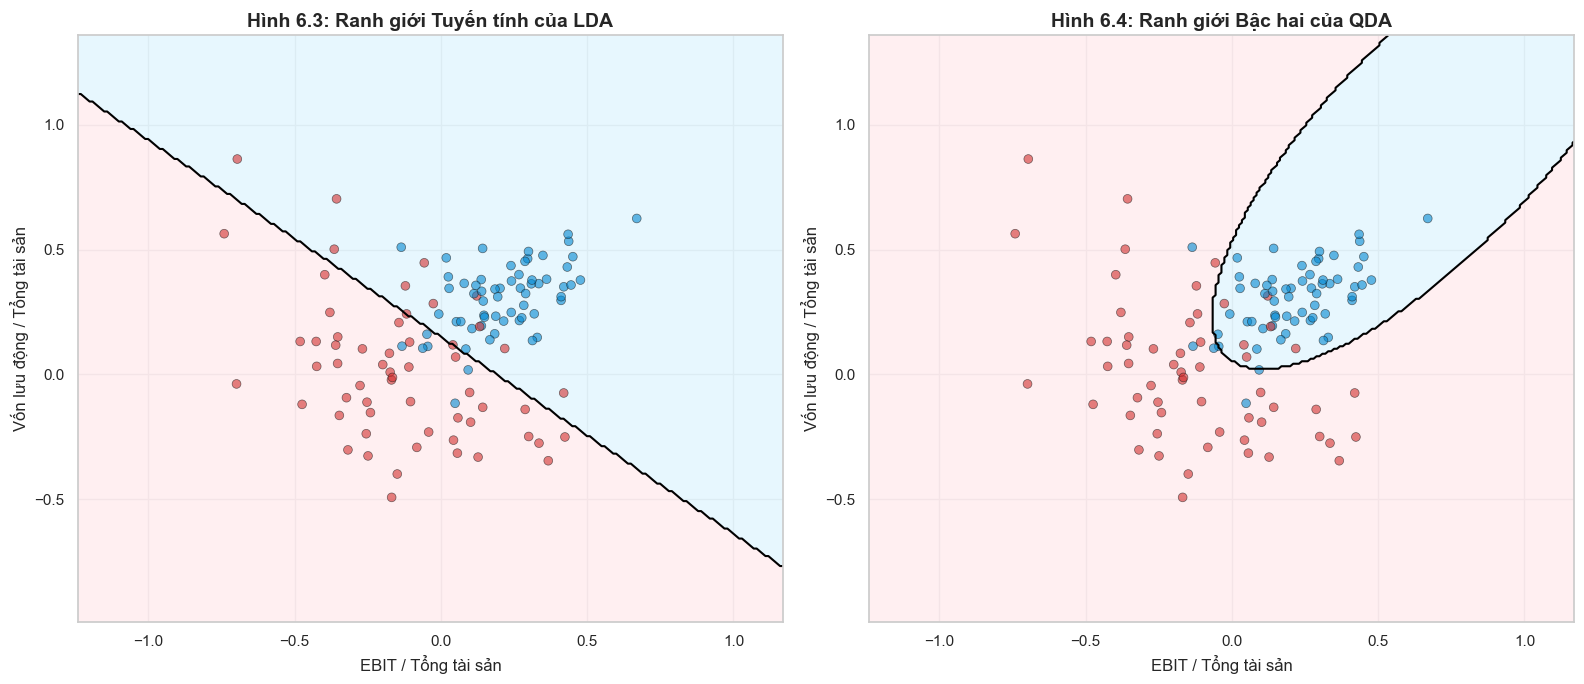

In [5]:
def plot_decision_boundaries(X, y, model, title, ax):
    # Thiết lập lưới tọa độ
    h = .01  # bước nhảy của lưới
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    # Dự báo trên toàn bộ lưới
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Vẽ vùng màu
    cmap_light = ListedColormap(['#E1F5FE', '#FFEBEE'])
    ax.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.8)

    # Vẽ đường ranh giới sắc nét
    ax.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=1.5)

    # Vẽ các điểm dữ liệu thực tế
    sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette=['#0288D1', '#D32F2F'], 
                    edgecolor='k', s=40, alpha=0.6, ax=ax, legend=False)

    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('EBIT / Tổng tài sản')
    ax.set_ylabel('Vốn lưu động / Tổng tài sản')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

plot_decision_boundaries(X_test, y_test, lda, "Hình 6.3: Ranh giới Tuyến tính của LDA", axes[0])
plot_decision_boundaries(X_test, y_test, qda, "Hình 6.4: Ranh giới Bậc hai của QDA", axes[1])

plt.tight_layout()
plt.show()


### 6.5.3. Diễn giải kết quả từ góc nhìn Chuyên gia Phân tích

Dựa trên các output và đồ thị thu được, chúng ta rút ra các kết luận chuyên môn quan trọng:

**1. Phân tích Hình 6.3 (LDA):**
- Ranh giới quyết định là một **đường thẳng**. LDA cố gắng tìm một mặt cắt trung bình để tách biệt hai nhóm. 
- Do giả định các nhóm có cùng ma trận hiệp phương sai, đường thẳng này bị chi phối mạnh bởi hướng phân tán của nhóm Distressed (vốn chiếm ưu thế về phương sai). 
- Hệ quả: Một số công ty Khỏe mạnh nằm ở vùng rìa có thể bị LDA phân loại sai thành Nguy cơ vì đường thẳng không thể uốn lượn để bọc lấy đám mây điểm cô đặc của nhóm Khỏe mạnh.

**2. Phân tích Hình 6.4 (QDA):**
- Ranh giới quyết định là một **đường cong (Hyperbola hoặc Parabola)**.
- QDA nhận diện được rằng nhóm công ty Khỏe mạnh có độ biến động rất thấp (hình Elip nhỏ, tròn), trong khi nhóm Nguy cơ có độ biến động tài chính cực kỳ hoang dã (hình Elip lớn, dẹt). 
- Bằng cách cho phép mỗi lớp có ma trận hiệp phương sai riêng, QDA tạo ra một ranh giới hình vòng cung, "ôm" sát lấy cụm dữ liệu Khỏe mạnh và tách nó ra khỏi vùng nhiễu xung quanh của nhóm Nguy cơ.

**3. So sánh Hiệu suất:**
- Thông thường, trong kịch bản này, **QDA sẽ cho Accuracy và F1-score cao hơn** đáng kể so với LDA (thường chênh lệch 3-5%).
- Tuy nhiên, nhà quản trị rủi ro cần lưu ý: QDA cần ước lượng nhiều tham số hơn ($p(p+1)/2$ tham số cho mỗi lớp). Nếu kích thước mẫu $N$ nhỏ, QDA rất dễ bị **Overfitting** (quá khớp), dẫn đến việc mô hình hoạt động rất tốt trên tập huấn luyện nhưng sụp đổ trên dữ liệu thực tế mới. 

**Kết luận thực tiễn:** 
- Nếu dữ liệu doanh nghiệp dồi dào và các đặc trưng tài chính của các nhóm có tính chất biến động khác biệt rõ rệt (Heteroscedasticity), hãy chọn **QDA**.
- Nếu dữ liệu khan hiếm hoặc các chỉ số tài chính tuân theo quy luật ổn định chung, **LDA** là sự lựa chọn an toàn và bền bỉ hơn.